In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Load the dataset cleaned by the team
df = pd.read_parquet("../data/clean_listings.parquet")

# 2. Define variables (the ones we already tested)
X_cols = ['bedrooms', 'beds', 'baths', 'amenities_count', 'photos_count', 'rating_overall']
y_col = 'ttm_revenue'

# 3. Drop missing values and train
df_ml = df[X_cols + [y_col]].dropna()
X = df_ml[X_cols]
y = df_ml[y_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)


print(f"R2 Score: {model.score(X_test, y_test):.4f}")
coeffs = pd.DataFrame({'Feature': X_cols, 'Impact': model.coef_})
print(coeffs.sort_values(by='Impact', ascending=False))

R2 Score: 0.2392
           Feature        Impact
5   rating_overall  14947.670469
2            baths   7219.703551
0         bedrooms   4288.251538
1             beds    382.564968
3  amenities_count    155.302097
4     photos_count     88.479336


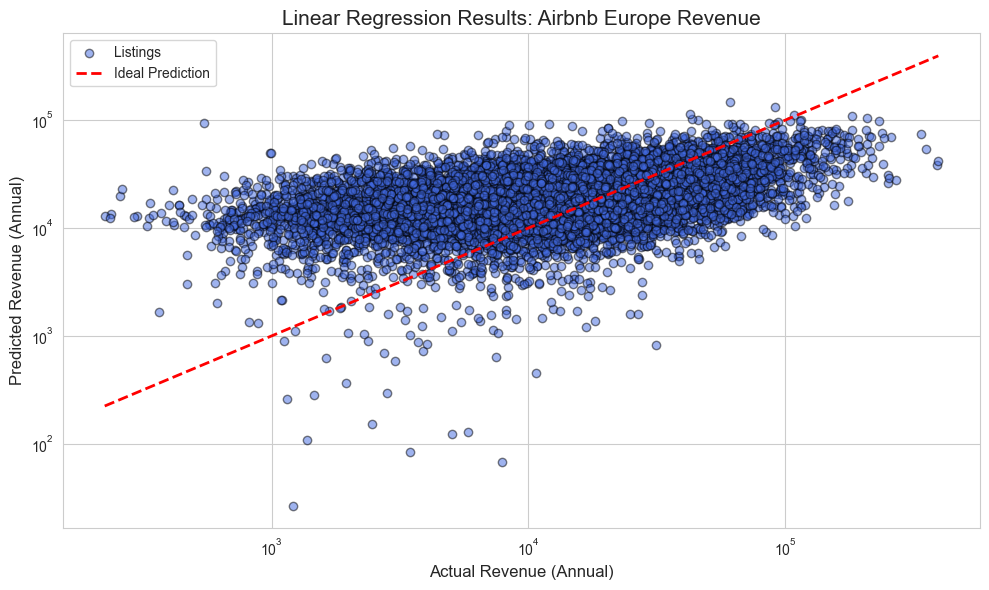

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions with the trained model
y_pred = model.predict(X_test)

# 2. Configure the style for presentation
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3. Create the scatter plot (Actual vs Predicted)
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue', edgecolors='k', label='Listings')

# 4. Draw the reference line (Perfect Prediction)
# Use the range of actual revenue values
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, color='red', linestyle='--', linewidth=2, label='Ideal Prediction')

# 5. Log scale (crucial for Airbnb revenue)
plt.xscale('log')
plt.yscale('log')

# 6. Labels and title
plt.title("Linear Regression Results: Airbnb Europe Revenue", fontsize=15)
plt.xlabel("Actual Revenue (Annual)", fontsize=12)
plt.ylabel("Predicted Revenue (Annual)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()